# Task
Build, evaluate, and visualize a machine learning model to predict healthcare diagnoses based on patient health data, using metrics such as sensitivity, specificity, accuracy, and F1-score, and then summarize its performance, implications, and next steps.

## Load Patient Data

### Subtask:
Load the patient health data from the provided dataset into a pandas DataFrame. I will expect a structured dataset containing symptoms, medical history, laboratory test results, and diagnostic outcomes.


**Reasoning**:
First, I need to import the pandas library, then load the data from 'healthcare_dataset.csv' into a DataFrame, and finally display the first 5 rows to ensure it loaded correctly.



In [2]:
import pandas as pd
df = pd.read_csv('/content/healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Handle missing values in 'bmi' column
df['bmi'].fillna(df['bmi'].mean(), inplace=True)
print("Missing values after BMI imputation:")
print(df.isnull().sum())

# 2. Examine 'gender' column and remove 'Other' category if present
if 'Other' in df['gender'].unique():
    df = df[df['gender'] != 'Other']
    print("\n'Other' gender category removed.")

# 3. Apply one-hot encoding to categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nDataFrame after one-hot encoding:")
print(df_encoded.head())

# 4. Initialize a StandardScaler and apply it to scale numerical features
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])
print("\nDataFrame after numerical feature scaling:")
print(df_encoded.head())

# 5. Separate features (X) and target variable (y)
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']
print("\nShape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

# 6. Split the preprocessed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Missing values after BMI imputation:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

'Other' gender category removed.

DataFrame after one-hot encoding:
      id   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0   9046  67.0             0              1             228.69  36.600000   
1  51676  61.0             0              0             202.21  28.893237   
2  31112  80.0             0              1             105.92  32.500000   
3  60182  49.0             0              0             171.23  34.400000   
4   1665  79.0             1              0             174.12  24.000000   

   stroke  gender_Male  ever_married_Yes  work_type_Never_worked  \
0       1         True              True                   False   
1     

/tmp/ipython-input-3356688995.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bmi'].fillna(df['bmi'].mean(), inplace=True)


In [4]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Handle missing values in 'bmi' column
df['bmi'] = df['bmi'].fillna(df['bmi'].mean())
print("Missing values after BMI imputation:")
print(df.isnull().sum())

# 2. Examine 'gender' column and remove 'Other' category if present
if 'Other' in df['gender'].unique():
    df = df[df['gender'] != 'Other']
    print("\n'Other' gender category removed.")

# 3. Apply one-hot encoding to categorical columns
categorical_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nDataFrame after one-hot encoding:")
print(df_encoded.head())

# 4. Initialize a StandardScaler and apply it to scale numerical features
numerical_cols = ['age', 'avg_glucose_level', 'bmi']
scaler = StandardScaler()
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])
print("\nDataFrame after numerical feature scaling:")
print(df_encoded.head())

# 5. Separate features (X) and target variable (y)
X = df_encoded.drop('stroke', axis=1)
y = df_encoded['stroke']
print("\nShape of features (X):", X.shape)
print("Shape of target (y):", y.shape)

# 6. Split the preprocessed data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nShape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)


Missing values after BMI imputation:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

DataFrame after one-hot encoding:
      id   age  hypertension  heart_disease  avg_glucose_level        bmi  \
0   9046  67.0             0              1             228.69  36.600000   
1  51676  61.0             0              0             202.21  28.893237   
2  31112  80.0             0              1             105.92  32.500000   
3  60182  49.0             0              0             171.23  34.400000   
4   1665  79.0             1              0             174.12  24.000000   

   stroke  gender_Male  ever_married_Yes  work_type_Never_worked  \
0       1         True              True                   False   
1       1        False              True

In [5]:
from sklearn.linear_model import LogisticRegression

# 1. Remove the 'id' column from both X_train and X_test
X_train = X_train.drop('id', axis=1)
X_test = X_test.drop('id', axis=1)
print("X_train shape after removing 'id':", X_train.shape)
print("X_test shape after removing 'id':", X_test.shape)

# 2. Instantiate a LogisticRegression model
model = LogisticRegression(random_state=42, solver='liblinear')

# 3. Train the logistic regression model
model.fit(X_train, y_train)
print("\nLogistic Regression model trained successfully.")

X_train shape after removing 'id': (4087, 15)
X_test shape after removing 'id': (1022, 15)

Logistic Regression model trained successfully.


In [6]:
from sklearn.metrics import confusion_matrix

# 1. Use the trained model to make predictions on the X_test data
y_pred = model.predict(X_test)
print("Predictions made successfully.")

# 2. Calculate the confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# 3. Extract True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN)
TN, FP, FN, TP = cm.ravel()

# 4. Calculate Accuracy
accuracy = (TP + TN) / (TP + TN + FP + FN)

# 5. Calculate Sensitivity (Recall)
sensitivity = TP / (TP + FN) if (TP + FN) != 0 else 0

# 6. Calculate Specificity
specificity = TN / (TN + FP) if (TN + FP) != 0 else 0

# 7. Calculate Precision
precision = TP / (TP + FP) if (TP + FP) != 0 else 0

# 8. Calculate F1-Score
f1_score = 2 * (precision * sensitivity) / (precision + sensitivity) if (precision + sensitivity) != 0 else 0

# 9. Print all the calculated metrics
print(f"\nAccuracy: {accuracy:.4f}")
print(f"Sensitivity: {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1-Score: {f1_score:.4f}")

Predictions made successfully.

Confusion Matrix:
 [[960   0]
 [ 62   0]]

Accuracy: 0.9393
Sensitivity: 0.0000
Specificity: 1.0000
Precision: 0.0000
F1-Score: 0.0000


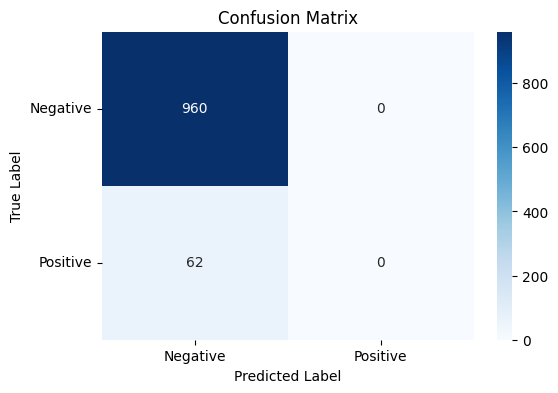

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a heatmap of the confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Add labels to the x-axis for predicted classes
plt.xlabel('Predicted Label')
plt.xticks([0.5, 1.5], ['Negative', 'Positive'])

# Add labels to the y-axis for true classes
plt.ylabel('True Label')
plt.yticks([0.5, 1.5], ['Negative', 'Positive'], rotation=0)

# Add a title to the heatmap
plt.title('Confusion Matrix')

# Display the plot
plt.show()


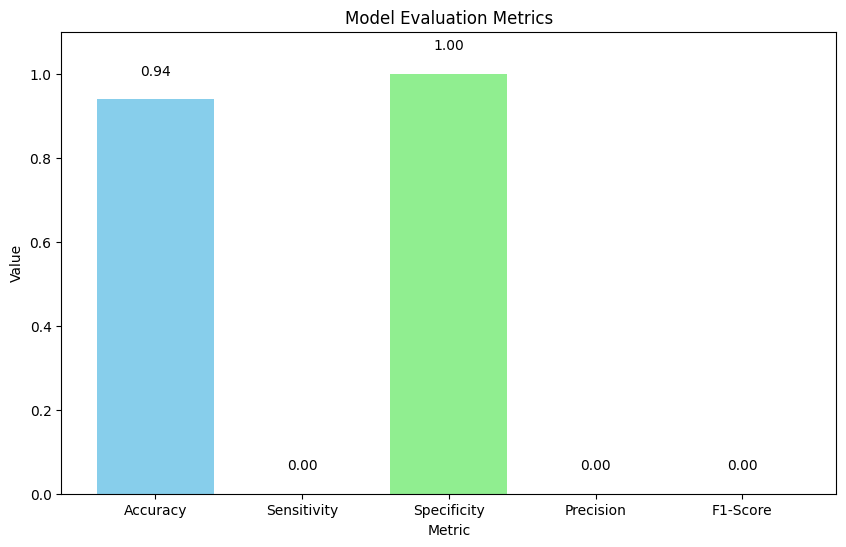

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for the bar chart
metrics_names = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F1-Score']
metrics_values = [accuracy, sensitivity, specificity, precision, f1_score]

# Create a bar chart for the evaluation metrics
plt.figure(figsize=(10, 6))
plt.bar(metrics_names, metrics_values, color=['skyblue', 'lightcoral', 'lightgreen', 'gold', 'violet'])

# Add labels and title
plt.xlabel('Metric')
plt.ylabel('Value')
plt.title('Model Evaluation Metrics')
plt.ylim(0, 1.1) # Set y-axis limit from 0 to 1.1 for better visualization of scores

# Add value labels on top of each bar
for i, value in enumerate(metrics_values):
    plt.text(i, value + 0.05, f'{value:.2f}', ha='center', va='bottom')

# Display the plot
plt.show()